In [4]:
import pandas as pd

In [7]:
df = pd.read_csv("data/2010-2025_scores.csv")
df.head()

,Season,Week,GameStatus,GameSlot,GameDate,AwayTeam,AwayScore,HomeTeam,HomeScore
0,2010,HALL OF FAME,FINAL,Sunday,August 8th,DAL,16.0,CIN,7.0
1,2010,PRESEASON WEEK 1,FINAL,Thursday,August 12th,CAR,12.0,BAL,17.0
2,2010,PRESEASON WEEK 1,FINAL,Thursday,August 12th,NO,24.0,NE,27.0
3,2010,PRESEASON WEEK 1,FINAL,Thursday,August 12th,OAK,17.0,DAL,9.0
4,2010,PRESEASON WEEK 1,FINAL,Friday,August 13th,BUF,17.0,WAS,42.0


In [8]:
# 2. Filter out seasons prior to 2011
df = df[df['Season'] >= 2011]

# 3. Filter to keep only regular season games
# Regular season weeks are named "WEEK 1", "WEEK 2", etc.
df = df[df['Week'].str.startswith('WEEK')]

# 4. Reset the index after dropping rows so our dataframe is clean
df = df.reset_index(drop=True)

# Inspect the cleaned dataset
print(f"Total regular season games from 2011 onwards: {len(df)}")
print(df.head())

Total regular season games from 2011 onwards: 4398
   Season    Week GameStatus  GameSlot        GameDate AwayTeam  AwayScore  \
0    2011  WEEK 1      FINAL  Thursday   September 8th       NO       34.0   
1    2011  WEEK 1      FINAL    Sunday  September 11th      PIT        7.0   
2    2011  WEEK 1      FINAL    Sunday  September 11th      CIN       27.0   
3    2011  WEEK 1      FINAL    Sunday  September 11th      IND        7.0   
4    2011  WEEK 1      FINAL    Sunday  September 11th      TEN       14.0   

  HomeTeam  HomeScore  
0       GB       42.0  
1      BAL       35.0  
2      CLE       17.0  
3      HOU       34.0  
4      JAC       16.0  


In [9]:
# 5. Remove BYE weeks (where no game is actually played)
df = df[df['GameStatus'] != 'BYE']
df = df.dropna(subset=['GameDate']).reset_index(drop=True)

# 6. Function to parse actual date accounting for Jan/Feb games
def parse_actual_date(row):
    season = row['Season']
    # Remove ordinal suffixes from the GameDate string (e.g., '8th' -> '8')
    date_str = str(row['GameDate']).replace('th','').replace('st','').replace('nd','').replace('rd','')
    
    # Check if the month is January or February to adjust the year
    if date_str.startswith('Jan') or date_str.startswith('Feb'):
        year = season + 1
    else:
        year = season
        
    return pd.to_datetime(f"{year} {date_str}", format="%Y %B %d")

# 7. Apply the function to create a new 'Date' column
df['Date'] = df.apply(parse_actual_date, axis=1)

# 8. Sort the entire dataframe by Date to ensure chronological order
df = df.sort_values('Date').reset_index(drop=True)

print("Check regular season dates at the start:")
print(df[['Season', 'Week', 'GameDate', 'Date']].head(3))

print("\nCheck dates that spill into January:")
print(df[df['Date'].dt.month == 1][['Season', 'Week', 'GameDate', 'Date']].head(3))

Check regular season dates at the start:
   Season    Week        GameDate       Date
0    2011  WEEK 1   September 8th 2011-09-08
1    2011  WEEK 1  September 11th 2011-09-11
2    2011  WEEK 1  September 11th 2011-09-11

Check dates that spill into January:
     Season     Week     GameDate       Date
240    2011  WEEK 17  January 1st 2012-01-01
241    2011  WEEK 17  January 1st 2012-01-01
242    2011  WEEK 17  January 1st 2012-01-01


In [11]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])

# --- STEP 2: TRACK TEAM SCHEDULES ---

# Create temporary dataframes for Home and Away 
home_df = df[['Season', 'Date', 'HomeTeam']].rename(columns={'HomeTeam': 'Team'})
away_df = df[['Season', 'Date', 'AwayTeam']].rename(columns={'AwayTeam': 'Team'})

# Combine them to get a master list of all games played by every team
team_df = pd.concat([home_df, away_df]).sort_values(['Team', 'Date']).reset_index(drop=True)

# Calculate rest days grouped by Season AND Team using .diff()
team_df['Rest_Days'] = team_df.groupby(['Season', 'Team'])['Date'].diff().dt.days


# --- STEP 3: JOIN REST BACK TO MATCHUPS ---

# Join the calculated rest back to the Home team
df = df.merge(team_df[['Date', 'Team', 'Rest_Days']], 
              left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
df = df.rename(columns={'Rest_Days': 'Home_Rest'}).drop('Team', axis=1)

# Join the calculated rest back to the Away team
df = df.merge(team_df[['Date', 'Team', 'Rest_Days']], 
              left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
df = df.rename(columns={'Rest_Days': 'Away_Rest'}).drop('Team', axis=1)

# Calculate the Rest Advantage
# Positive = Home has more rest, Negative = Away has more rest, 0 = Equal rest
df['Home_Rest_Advantage'] = df['Home_Rest'] - df['Away_Rest']

# Print a sample of Week 2 games to see it in action!
print(df[['Season', 'Week', 'AwayTeam', 'Away_Rest', 'HomeTeam', 'Home_Rest', 'Home_Rest_Advantage']].dropna().head(10))

    Season    Week AwayTeam  Away_Rest HomeTeam  Home_Rest  \
16    2011  WEEK 2      CHI        7.0       NO       10.0   
17    2011  WEEK 2      PHI        7.0      ATL        7.0   
18    2011  WEEK 2      HOU        7.0      MIA        6.0   
19    2011  WEEK 2      CIN        7.0      DEN        6.0   
20    2011  WEEK 2      DAL        7.0       SF        7.0   
21    2011  WEEK 2      SEA        7.0      PIT        7.0   
22    2011  WEEK 2       GB       10.0      CAR        7.0   
23    2011  WEEK 2       SD        7.0       NE        6.0   
24    2011  WEEK 2      ARI        7.0      WAS        7.0   
25    2011  WEEK 2      CLE        7.0      IND        7.0   

    Home_Rest_Advantage  
16                  3.0  
17                  0.0  
18                 -1.0  
19                 -1.0  
20                  0.0  
21                  0.0  
22                 -3.0  
23                 -1.0  
24                  0.0  
25                  0.0  


In [16]:
df.head(18)

,Season,Week,GameStatus,GameSlot,GameDate,AwayTeam,AwayScore,HomeTeam,HomeScore,Date,Home_Rest,Away_Rest,Home_Rest_Advantage
0,2011,WEEK 1,FINAL,Thursday,September 8th,NO,34.0,GB,42.0,2011-09-08,NaN,NaN,NaN
1,2011,WEEK 1,FINAL,Sunday,September 11th,DAL,24.0,NYJ,27.0,2011-09-11,NaN,NaN,NaN
2,2011,WEEK 1,FINAL,Sunday,September 11th,MIN,17.0,SD,24.0,2011-09-11,NaN,NaN,NaN
3,2011,WEEK 1,FINAL,Sunday,September 11th,CAR,21.0,ARI,28.0,2011-09-11,NaN,NaN,NaN
4,2011,WEEK 1,FINAL,Sunday,September 11th,NYG,14.0,WAS,28.0,2011-09-11,NaN,NaN,NaN
5,2011,WEEK 1,FINAL,Sunday,September 11th,PHI,31.0,STL,13.0,2011-09-11,NaN,NaN,NaN
6,2011,WEEK 1,FINAL,Sunday,September 11th,DET,27.0,TB,20.0,2011-09-11,NaN,NaN,NaN
7,2011,WEEK 1,FINAL,Sunday,September 11th,SEA,17.0,SF,33.0,2011-09-11,NaN,NaN,NaN
8,2011,WEEK 1,FINAL,Sunday,September 11th,BUF,41.0,KC,7.0,2011-09-11,NaN,NaN,NaN
9,2011,WEEK 1,FINAL,Sunday,September 11th,TEN,14.0,JAC,16.0,2011-09-11,NaN,NaN,NaN


In [17]:
# Determine the winner of the game (1 = Home Win, -1 = Away Win, 0 = Tie)
df['Home_Win'] = df.apply(lambda x: 1 if x['HomeScore'] > x['AwayScore'] else (-1 if x['AwayScore'] > x['HomeScore'] else 0), axis=1)

# Filter to only the games where ONE team had a rest advantage
games_with_advantage = df[df['Home_Rest_Advantage'] != 0].copy()

# Function to look at the game from the perspective of the Advantaged Team
def get_advantage_result(row):
    if row['Home_Rest_Advantage'] > 0:
        # Home team had the advantage
        adv_days = row['Home_Rest_Advantage']
        win_val = 1 if row['Home_Win'] == 1 else (0 if row['Home_Win'] == -1 else 0.5)
    else:
        # Away team had the advantage
        adv_days = abs(row['Home_Rest_Advantage'])
        win_val = 1 if row['Home_Win'] == -1 else (0 if row['Home_Win'] == 1 else 0.5)
        
    return pd.Series({'Rest_Advantage': adv_days, 'Win': win_val})

# Apply the function
results = games_with_advantage.apply(get_advantage_result, axis=1)

# Group the advantages into your requested buckets
def categorize_advantage(days):
    if 1 <= days <= 3:
        return '1 to 3 days'
    elif 4 <= days <= 6:
        return '4 to 6 days'
    elif days >= 7:
        return '7+ days'

results['Category'] = results['Rest_Advantage'].apply(categorize_advantage)

# Calculate the final win percentages!
summary = results.groupby('Category').agg(
    Total_Games=('Win', 'count'),
    Wins=('Win', 'sum') 
)
# Win Percentage = (Wins + 0.5 * Ties) / Total Games
summary['Win_Percentage'] = (summary['Wins'] / summary['Total_Games']) * 100

print(summary)

             Total_Games   Wins  Win_Percentage
Category                                       
1 to 3 days          935  450.0       48.128342
4 to 6 days           99   54.0       54.545455
7+ days              343  180.5       52.623907


In [19]:
# --- 1. CALCULATE EQUAL REST BASELINE ---
zero_adv = df[df['Home_Rest_Advantage'] == 0]

# Tally the outcomes (Tie = 0.5 wins)
home_wins = sum(zero_adv['HomeScore'] > zero_adv['AwayScore'])
away_wins = sum(zero_adv['HomeScore'] < zero_adv['AwayScore'])
ties = sum(zero_adv['HomeScore'] == zero_adv['AwayScore'])
total_zero = len(zero_adv)

print(f"--- EQUAL REST BASELINE ({total_zero} Games) ---")
print(f"Home Win Rate: {(home_wins + 0.5 * ties) / total_zero * 100:.2f}%")
print(f"Away Win Rate: {(away_wins + 0.5 * ties) / total_zero * 100:.2f}%\n")


# --- 2. CALCULATE ADVANTAGE SPLITS ---
def get_detailed_result(row):
    adv_days = row['Home_Rest_Advantage']
    if adv_days == 0:
        return None  # Skip equal rest games here
        
    is_home_adv = adv_days > 0
    days = abs(adv_days)
    
    # Did the advantaged team win?
    if is_home_adv:
        win_val = 1 if row['HomeScore'] > row['AwayScore'] else (0 if row['AwayScore'] > row['HomeScore'] else 0.5)
    else:
        win_val = 1 if row['AwayScore'] > row['HomeScore'] else (0 if row['HomeScore'] > row['AwayScore'] else 0.5)
        
    # Categorize the days
    if 1 <= days <= 2:
        cat = '1-2 days'
    elif 3 <= days <= 5:
        cat = '3-5 days'
    else:
        cat = '6+ days'
        
    return pd.Series({
        'Category': cat,
        'Advantaged_Team': 'Home' if is_home_adv else 'Away',
        'Win': win_val
    })

# Apply function and drop the empty 'None' rows (the zero rest games)
results = df.apply(get_detailed_result, axis=1).dropna()

# Group by who had the advantage and the size of the advantage
summary = results.groupby(['Advantaged_Team', 'Category']).agg(
    Total_Games=('Win', 'count'),
    Wins=('Win', 'sum')
)
summary['Win_Percentage'] = (summary['Wins'] / summary['Total_Games']) * 100

print("--- WIN % FOR THE TEAM WITH THE ADVANTAGE ---")
print(summary)

--- EQUAL REST BASELINE (2302 Games) ---
Home Win Rate: 55.71%
Away Win Rate: 44.24%

--- WIN % FOR THE TEAM WITH THE ADVANTAGE ---
                          Total_Games   Wins  Win_Percentage
Advantaged_Team Category                                    
Away            1-2 days          290  126.0       43.448276
                3-5 days          277  124.5       44.945848
                6+ days           441  208.0       47.165533
Home            1-2 days          227  122.0       53.744493
                3-5 days          207  113.5       54.830918
                6+ days           176  103.0       58.522727


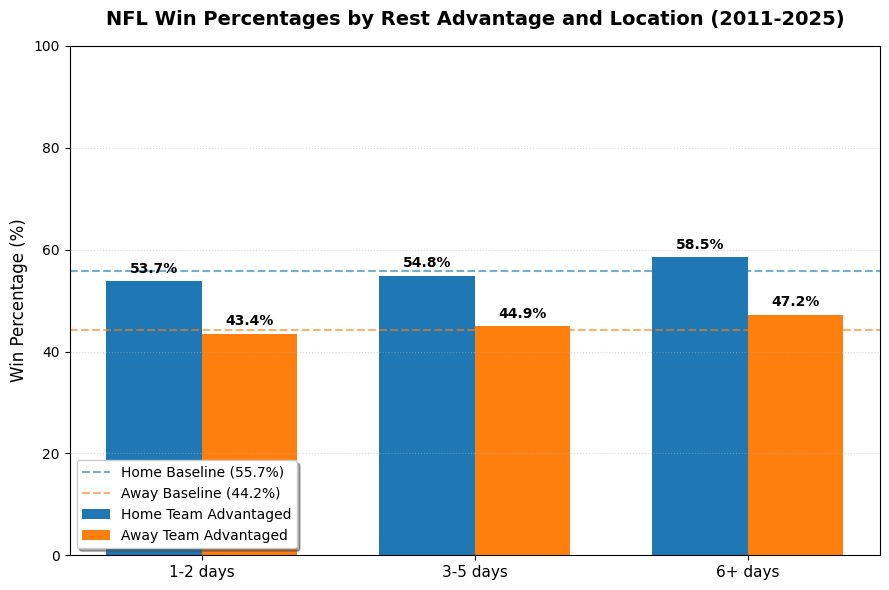

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Calculate the "Equal Rest" Baselines
zero_adv = df[df['Home_Rest_Advantage'] == 0]
home_wins_0 = sum(zero_adv['HomeScore'] > zero_adv['AwayScore'])
away_wins_0 = sum(zero_adv['HomeScore'] < zero_adv['AwayScore'])
ties_0 = sum(zero_adv['HomeScore'] == zero_adv['AwayScore'])
total_0 = len(zero_adv)

home_baseline = (home_wins_0 + 0.5 * ties_0) / total_0 * 100
away_baseline = (away_wins_0 + 0.5 * ties_0) / total_0 * 100


# 4. Aggregate results to find win percentages
summary = results.groupby(['Advantaged_Team', 'Category']).agg(
    Total_Games=('Win', 'count'),
    Wins=('Win', 'sum')
)
summary['Win_Percentage'] = (summary['Wins'] / summary['Total_Games']) * 100

# Reshape data to make plotting easy
plot_df = summary['Win_Percentage'].unstack(level=0)


# --- 5. GRAPHING THE DATA ---
categories = ['1-2 days', '3-5 days', '6+ days']
home_win_pcts = [plot_df.loc[cat, 'Home'] for cat in categories]
away_win_pcts = [plot_df.loc[cat, 'Away'] for cat in categories]

x = np.arange(len(categories))
width = 0.35

# Set up subplots (avoiding plt.figure for script stability)
fig, ax = plt.subplots(figsize=(9, 6))

# Plot bars for Home and Away advantages
rects1 = ax.bar(x - width/2, home_win_pcts, width, label='Home Team Advantaged', color='#1f77b4')
rects2 = ax.bar(x + width/2, away_win_pcts, width, label='Away Team Advantaged', color='#ff7f0e')

# Draw baseline dashed lines for context
ax.axhline(y=home_baseline, color='#1f77b4', linestyle='--', alpha=0.6, label=f'Home Baseline ({home_baseline:.1f}%)')
ax.axhline(y=away_baseline, color='#ff7f0e', linestyle='--', alpha=0.6, label=f'Away Baseline ({away_baseline:.1f}%)')

# Labels and layout styling
ax.set_ylabel('Win Percentage (%)', fontsize=12)
ax.set_title('NFL Win Percentages by Rest Advantage and Location (2011-2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.legend(loc='lower left', frameon=True, shadow=True)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Label helper to put percentage tags on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# Save the plot image
plt.savefig('nfl_rest_advantage_new_buckets.png', dpi=300)

In [24]:
import pandas as pd

# 1. Load the 2026 schedule
df = pd.read_csv('data/2026_schedule.csv')

# 2. Parse the dates (Handling September-December as 2026, and January as 2027)
def parse_date(date_str):
    year = 2027 if ('January' in date_str or 'February' in date_str) else 2026
    return pd.to_datetime(f"{year} {date_str}", format="%Y %B %d")

df['ParsedDate'] = df['Date'].apply(parse_date)

# 3. Create a master timeline of all team games to find previous dates
home_df = df[['Week', 'ParsedDate', 'HomeTm']].rename(columns={'HomeTm': 'Team'})
vis_df = df[['Week', 'ParsedDate', 'VisTm']].rename(columns={'VisTm': 'Team'})
team_timeline = pd.concat([home_df, vis_df]).sort_values(['Team', 'ParsedDate']).reset_index(drop=True)

# Calculate rest days between consecutive games for each team
team_timeline['Rest_Days'] = team_timeline.groupby('Team')['ParsedDate'].diff().dt.days

# 4. Map the calculated rest days back to the original schedule matchups
df = df.merge(team_timeline[['ParsedDate', 'Team', 'Rest_Days']], left_on=['ParsedDate', 'HomeTm'], right_on=['ParsedDate', 'Team'], how='left')
df = df.rename(columns={'Rest_Days': 'Home_Rest'}).drop('Team', axis=1)

df = df.merge(team_timeline[['ParsedDate', 'Team', 'Rest_Days']], left_on=['ParsedDate', 'VisTm'], right_on=['ParsedDate', 'Team'], how='left')
df = df.rename(columns={'Rest_Days': 'Vis_Rest'}).drop('Team', axis=1)

# Calculate Rest Advantage (Positive = Home advantage, Negative = Visitor advantage)
df['Home_Rest_Advantage'] = df['Home_Rest'] - df['Vis_Rest']

# 5. Count 6+ Day Rest Advantages and Disadvantages per team
teams = pd.concat([df['HomeTm'], df['VisTm']]).unique()
tally = {team: {'6+_Advantage': 0, '6+_Disadvantage': 0} for team in teams}

for _, row in df.iterrows():
    adv = row['Home_Rest_Advantage']
    if pd.isna(adv):
        continue
    
    home, vis = row['HomeTm'], row['VisTm']
    
    if adv >= 6:
        tally[home]['6+_Advantage'] += 1
        tally[vis]['6+_Disadvantage'] += 1
    elif adv <= -6:
        tally[vis]['6+_Advantage'] += 1
        tally[home]['6+_Disadvantage'] += 1

# Convert results to a clean summary DataFrame sorted by best scheduling luck
summary = pd.DataFrame.from_dict(tally, orient='index').reset_index()
summary.columns = ['Team', '6+ Day Advantages', '6+ Day Disadvantages']
summary = summary.sort_values(by=['6+ Day Advantages', '6+ Day Disadvantages'], ascending=[False, True]).reset_index(drop=True)

print(summary.to_string(index=False))

                 Team  6+ Day Advantages  6+ Day Disadvantages
     Seattle Seahawks                  1                     0
    Carolina Panthers                  1                     0
       Houston Texans                  1                     0
 Jacksonville Jaguars                  1                     0
      New York Giants                  1                     0
   Kansas City Chiefs                  1                     0
        Buffalo Bills                  1                     0
      Atlanta Falcons                  1                     0
        Chicago Bears                  1                     0
 New England Patriots                  1                     0
    Arizona Cardinals                  1                     0
       Dallas Cowboys                  1                     0
       Miami Dolphins                  1                     0
Washington Commanders                  1                     0
   Cincinnati Bengals                  1               

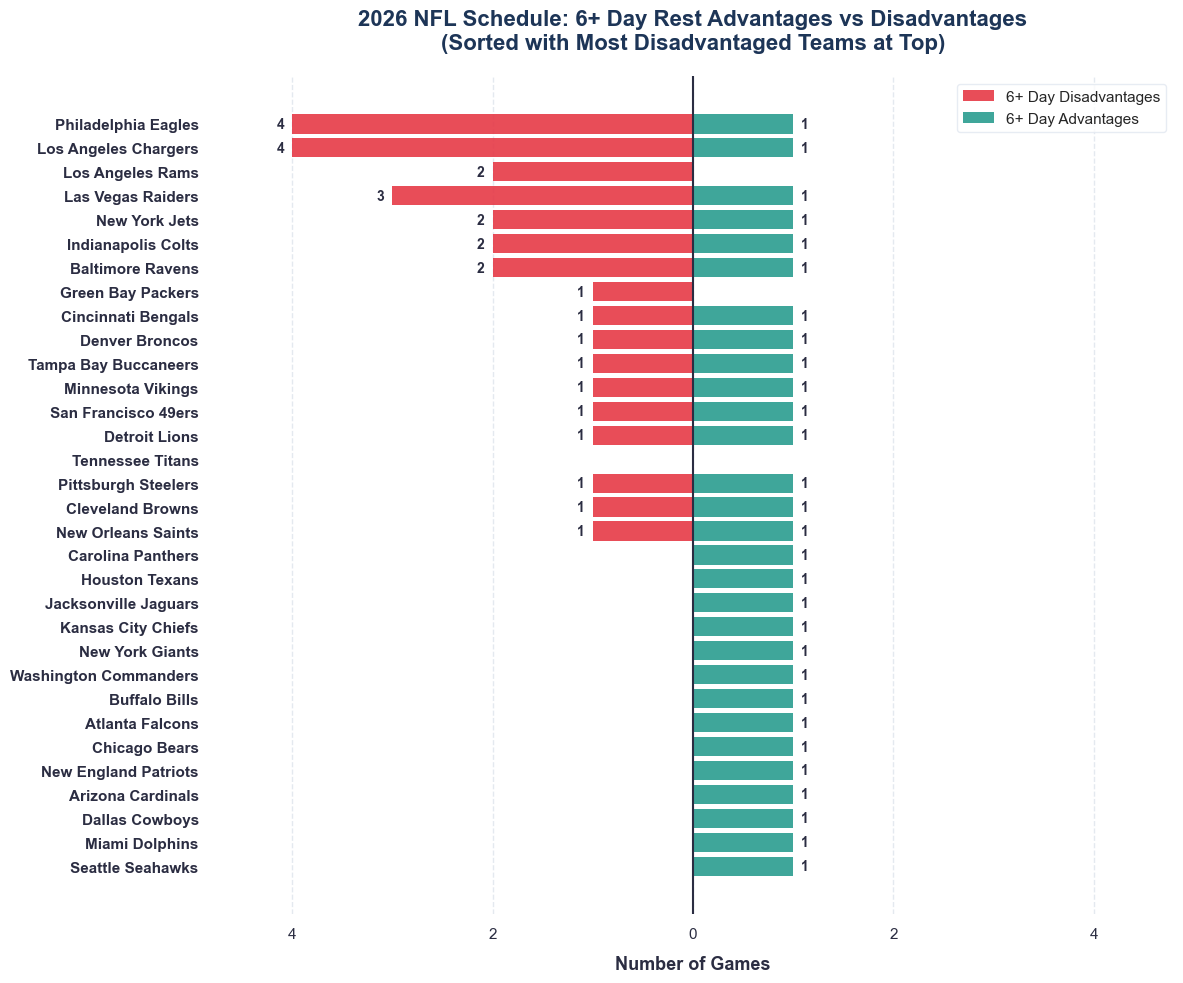

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the 2026 schedule with rest data
df_2026 = df

# 2. Tally 6+ day advantages and disadvantages per team
teams = pd.concat([df_2026['HomeTm'], df_2026['VisTm']]).unique()
tally = {team: {'Advantages': 0, 'Disadvantages': 0} for team in teams}

for _, row in df_2026.iterrows():
    adv = row['Home_Rest_Advantage']
    if pd.isna(adv):
        continue
    home, vis = row['HomeTm'], row['VisTm']
    if adv >= 6:
        tally[home]['Advantages'] += 1
        tally[vis]['Disadvantages'] += 1
    elif adv <= -6:
        tally[vis]['Advantages'] += 1
        tally[home]['Disadvantages'] += 1

summary = pd.DataFrame.from_dict(tally, orient='index').reset_index()
summary.columns = ['Team', 'Advantages', 'Disadvantages']
summary['Net_Disadvantages'] = summary['Disadvantages'] - summary['Advantages']

# Sort for plotting (ascending order ensures highest net disadvantages appear at the top)
summary = summary.sort_values(by='Net_Disadvantages', ascending=True).reset_index(drop=True)

# --- 3. SEABORN & MATPLOTLIB PLOTTING ---
# Set clean seaborn theme configurations
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 10))
y_pos = np.arange(len(summary))

# Soft modern flat palettes
red_color = "#e63946"   # Soft Crimson
green_color = "#2a9d8f"  # Elegant Teal-Green

# Build bi-directional horizontal bar elements
ax.barh(y_pos, -summary['Disadvantages'], color=red_color, edgecolor='none', alpha=0.9, label='6+ Day Disadvantages')
ax.barh(y_pos, summary['Advantages'], color=green_color, edgecolor='none', alpha=0.9, label='6+ Day Advantages')

# Format y-axis team text labels
ax.set_yticks(y_pos)
ax.set_yticklabels(summary['Team'], fontsize=11, fontweight='semibold', color='#2b2d42')

# Draw a bold center margin separator
ax.axvline(x=0, color='#2b2d42', linewidth=1.5, linestyle='-')

# Chart labels and title styling
ax.set_xlabel('Number of Games', fontsize=13, fontweight='bold', labelpad=10, color='#2b2d42')
ax.set_title('2026 NFL Schedule: 6+ Day Rest Advantages vs Disadvantages\n(Sorted with Most Disadvantaged Teams at Top)', 
             fontsize=16, fontweight='bold', pad=20, color='#1d3557')

# Append value labels directly outside the margins of the bars
for i in range(len(summary)):
    disadv = summary.loc[i, 'Disadvantages']
    adv = summary.loc[i, 'Advantages']
    
    if disadv > 0:
        ax.text(-disadv - 0.08, i, str(disadv), va='center', ha='right', color='#2b2d42', fontweight='bold', fontsize=10)
    if adv > 0:
        ax.text(adv + 0.08, i, str(adv), va='center', ha='left', color='#2b2d42', fontweight='bold', fontsize=10)

# Establish strict symmetric bounds
max_val = max(summary['Advantages'].max(), summary['Disadvantages'].max())
ax.set_xlim(-max_val - 0.8, max_val + 0.8)

# Format x-axis intervals to show pure absolute values (hiding negative labels)
ticks = ax.get_xticks()
ticks = [t for t in ticks if -max_val <= t <= max_val]
ax.set_xticks(ticks)
ax.set_xticklabels([str(int(abs(t))) for t in ticks], fontsize=11, color='#2b2d42')

# Legend and grid customization
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cbd5e1')
ax.yaxis.grid(False) # Turn off horizontal lines to reduce clutter

# Strip outer border spine boxes
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save high-resolution chart output
plt.savefig('nfl_2026_rest_disparities_seaborn.png', dpi=300)

# add in travel screwage for ultimate screwage index

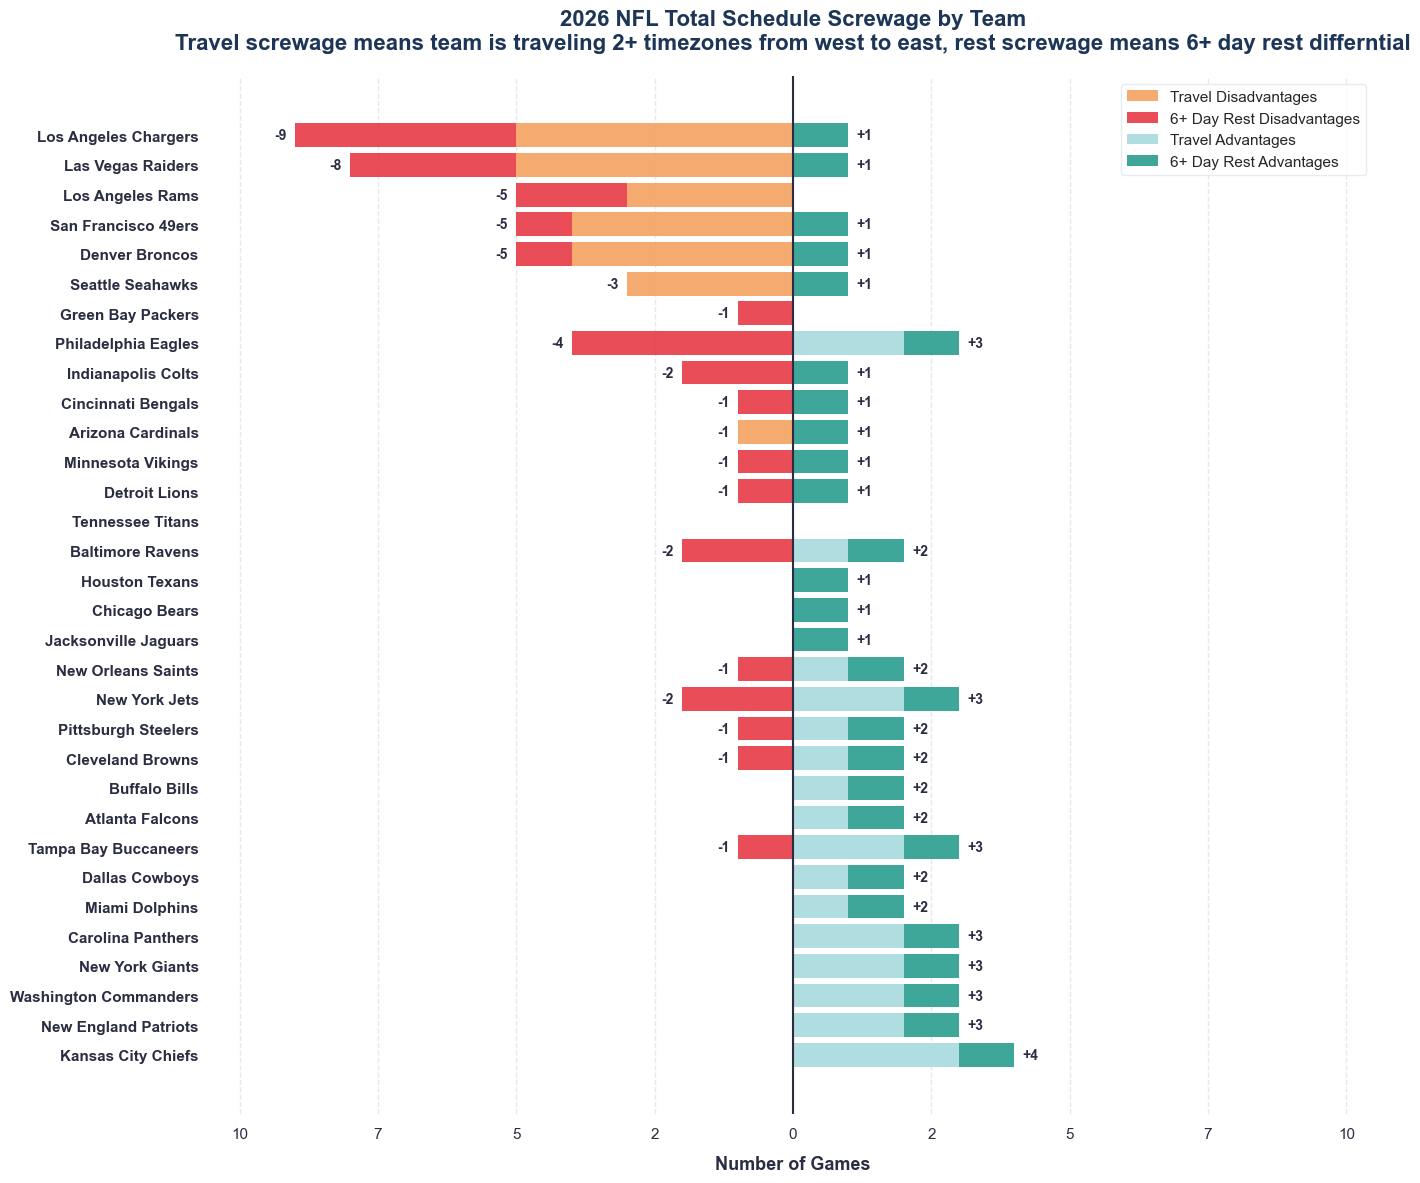

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_travel = pd.read_csv('2026_travel_screwage.csv').rename(columns={'Unnamed: 0': 'Team'})


rest_summary = summary.rename(columns = {'Advantages': 'Rest_Advantages', 'Disadvantages':'Rest_Disadvantages'})

# 3. Merge rest summaries with travel metrics
combined = pd.merge(rest_summary, df_travel, on='Team')

# 4. Calculate final totals and Net Screwage Score
combined['Total_Advantages'] = combined['Rest_Advantages'] + combined['Playing_Disadvantaged_Teams']
combined['Total_Disadvantages'] = combined['Rest_Disadvantages'] + combined['Own_Travel_Disadvantages']
combined['Total_Screwage'] = combined['Total_Disadvantages'] - combined['Total_Advantages']

# Sort for plotting (ascending order so most disadvantaged are at the top)
combined = combined.sort_values(by='Total_Screwage', ascending=True).reset_index(drop=True)


# --- 5. PLOTTING WITH SEABORN ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 12))
y_pos = np.arange(len(combined))

# Custom palettes
travel_dis_color = "#f4a261"  
rest_dis_color = "#e63946"    
travel_adv_color = "#a8dadc"  
rest_adv_color = "#2a9d8f"    

# Plot bars
ax.barh(y_pos, -combined['Own_Travel_Disadvantages'], color=travel_dis_color, edgecolor='none', alpha=0.9, label='Travel Disadvantages')
ax.barh(y_pos, -combined['Rest_Disadvantages'], left=-combined['Own_Travel_Disadvantages'], color=rest_dis_color, edgecolor='none', alpha=0.9, label='6+ Day Rest Disadvantages')
ax.barh(y_pos, combined['Playing_Disadvantaged_Teams'], color=travel_adv_color, edgecolor='none', alpha=0.9, label='Travel Advantages')
ax.barh(y_pos, combined['Rest_Advantages'], left=combined['Playing_Disadvantaged_Teams'], color=rest_adv_color, edgecolor='none', alpha=0.9, label='6+ Day Rest Advantages')

# Styling
ax.set_yticks(y_pos)
ax.set_yticklabels(combined['Team'], fontsize=11, fontweight='semibold', color='#2b2d42')
ax.axvline(x=0, color='#2b2d42', linewidth=1.5)

ax.set_xlabel('Number of Games', fontsize=13, fontweight='bold', labelpad=10, color='#2b2d42')
title = '2026 NFL Total Schedule Screwage by Team\nTravel screwage means team is traveling 2+ timezones from west to east, rest screwage means 6+ day rest differntial'
ax.set_title(title, 
             fontsize=16, fontweight='bold', pad=20, color='#1d3557')

# Text labels
for i in range(len(combined)):
    td, ta = combined.loc[i, 'Total_Disadvantages'], combined.loc[i, 'Total_Advantages']
    if td > 0: ax.text(-td - 0.15, i, f"-{td}", va='center', ha='right', color='#2b2d42', fontweight='bold', fontsize=10)
    if ta > 0: ax.text(ta + 0.15, i, f"+{ta}", va='center', ha='left', color='#2b2d42', fontweight='bold', fontsize=10)

# Set axes ticks/bounds
max_val = max(combined['Total_Advantages'].max(), combined['Total_Disadvantages'].max())
ax.set_xlim(-max_val - 1.5, max_val + 1.5)
ticks = [t for t in ax.get_xticks() if -max_val-1 <= t <= max_val+1]
ax.set_xticks(ticks)
ax.set_xticklabels([str(int(abs(t))) for t in ticks], fontsize=11, color='#2b2d42')

ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cbd5e1')
ax.yaxis.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('nfl_2026_total_screwage_seaborn.png', dpi=300)

In [33]:
summary.head()

,Team,Advantages,Disadvantages,Net_Disadvantages
0,Seattle Seahawks,1,0,-1
1,Miami Dolphins,1,0,-1
2,Dallas Cowboys,1,0,-1
3,Arizona Cardinals,1,0,-1
4,New England Patriots,1,0,-1
